In [1]:
from collections import OrderedDict
import re
import os
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from tqdm.notebook import tqdm

from google.colab import drive
drive.mount('/content/drive')
%cd 'drive/MyDrive/limits-of-icl/src'

!pip install wand munch

from eval import get_run_metrics, read_run_dir, get_model_from_run
from plot_utils import basic_plot, collect_results, relevant_model_names, plot_param_sweep, plot_experiment

%matplotlib inline
#%load_ext autoreload
#%autoreload 2

sns.set_theme('notebook', 'darkgrid')
palette = sns.color_palette('colorblind')

run_dir = "../models"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/limits-of-icl/src


In [2]:
df = read_run_dir(run_dir)
df  # list all the runs in our run_dir

../models/linear_regression/dabb65f6-7e9b-4b32-b796-2a5af901efd2/config.yaml
../models/linear_regression/pretrained/config.yaml
../models/linear_regression/nanogpt_local_100k_8/config.yaml
../models/linear_regression/nanogpt_local_100k_15/config.yaml
../models/linear_regression/nanogpt_mqa_100k/config.yaml
../models/linear_regression/nanogpt_local_100k_5/config.yaml
../models/linear_regression/nanogpt_softmax_100k/config.yaml
../models/linear_regression/nanogpt_softmax_test/config.yaml


,run_id,task,model,kwargs,num_tasks,num_examples,n_dims,n_layer,n_head,run_name
1,pretrained,linear_regression,Transformer,,-1,-1,20,12,8,linear_regression_pretrained
0,dabb65f6-7e9b-4b32-b796-2a5af901efd2,linear_regression,Transformer,,-1,-1,5,12,8,linear_regression_toy
3,nanogpt_local_100k_15,linear_regression,nanogpt_local_100k_15,,-1,-1,20,12,8,nanogpt_local_100k_15
5,nanogpt_local_100k_5,linear_regression,nanogpt_local_100k_5,,-1,-1,20,12,8,nanogpt_local_100k_5
2,nanogpt_local_100k_8,linear_regression,nanogpt_local_100k_8,,-1,-1,20,12,8,nanogpt_local_100k_8
4,nanogpt_mqa_100k,linear_regression,nanogpt_mqa_100k,,-1,-1,20,12,8,nanogpt_mqa_100k
6,nanogpt_softmax_100k,linear_regression,nanogpt_softmax_100k,,-1,-1,20,12,8,nanogpt_softmax_100k
7,nanogpt_softmax_test,linear_regression,nanogpt_softmax_test,,-1,-1,20,12,8,nanogpt_softmax_test


In [3]:
task = "linear_regression"
#task = "sparse_linear_regression"
#task = "decision_tree"
#task = "relu_2nn_regression"

# A list of models to compare - add more model run_ids here as needed
run_ids = ["nanogpt_local_100k_15", "nanogpt_local_100k_5", "nanogpt_local_100k_8", "nanogpt_mqa_100k", "nanogpt_softmax_100k"]

recompute_metrics = True  # Set to True to force recomputation

# Load metrics from each model's metrics.json and combine them
results = {}
for run_id in run_ids:
    run_path = os.path.join(run_dir, task, run_id)
    metrics_path = os.path.join(run_path, "metrics.json")

    model_metrics = None

    # Try to load existing metrics.json if not forcing recompute
    if not recompute_metrics and os.path.exists(metrics_path):
        try:
            with open(metrics_path, "r") as f:
                model_metrics = json.load(f)
            print(f"Loaded cached metrics for {run_id}")
        except (json.JSONDecodeError, ValueError) as e:
            print(f"Warning: metrics.json for {run_id} is corrupted or empty. Recomputing...")
            model_metrics = None

    # If metrics don't exist, are corrupted, or recompute is forced, compute them
    if model_metrics is None:
        print(f"Computing metrics for {run_id}...")
        model_metrics = get_run_metrics(run_path, cache=not recompute_metrics)

    # Add this model's metrics to results, organizing by experiment type
    for experiment_name, model_results in model_metrics.items():
        if experiment_name not in results:
            results[experiment_name] = {}
        # Add this model's results under the run_id as the model name
        for model_name, metrics in model_results.items():
            # Use run_id as the model identifier to distinguish different models
            combined_name = f"{run_id}" if ("nanogpt" in model_name or "gpt2" in model_name) else model_name
            results[experiment_name][combined_name] = metrics

# Optionally save combined results for reference
with open("results.json", "w") as f:
    json.dump(results, f, indent=4)

print(f"\nLoaded metrics from {len(run_ids)} models")
print(f"Experiment types: {list(results.keys())}")

Computing metrics for nanogpt_local_100k_15...
../models/linear_regression/nanogpt_local_100k_15/config.yaml
number of parameters: 9.48M
odict_keys(['_read_in.weight', '_read_in.bias', '_backbone.transformer.wpe.weight', '_backbone.transformer.h.0.ln_1.weight', '_backbone.transformer.h.0.ln_1.bias', '_backbone.transformer.h.0.attn.c_attn.weight', '_backbone.transformer.h.0.attn.c_attn.bias', '_backbone.transformer.h.0.attn.c_proj.weight', '_backbone.transformer.h.0.attn.c_proj.bias', '_backbone.transformer.h.0.ln_2.weight', '_backbone.transformer.h.0.ln_2.bias', '_backbone.transformer.h.0.mlp.c_fc.weight', '_backbone.transformer.h.0.mlp.c_fc.bias', '_backbone.transformer.h.0.mlp.c_proj.weight', '_backbone.transformer.h.0.mlp.c_proj.bias', '_backbone.transformer.h.1.ln_1.weight', '_backbone.transformer.h.1.ln_1.bias', '_backbone.transformer.h.1.attn.c_attn.weight', '_backbone.transformer.h.1.attn.c_attn.bias', '_backbone.transformer.h.1.attn.c_proj.weight', '_backbone.transformer.h.1.at

100%|██████████| 180/180 [02:50<00:00,  1.05it/s]


{'standard': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [5.3931193351745605], 'std': [13.089031219482422], 'bootstrap_low': [4.821347713470459], 'bootstrap_high': [6.00049352645874]}}, 'scaled_query_scale=0.1': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [0.37096524238586426], 'std': [1.0819040536880493], 'bootstrap_low': [0.3218948543071747], 'bootstrap_high': [0.4234446883201599]}}, 'scaled_query_scale=0.30000000000000004': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [0.7876996994018555], 'std': [1.8925153017044067], 'bootstrap_low': [0.7083495855331421], 'bootstrap_high': [0.8788549304008484]}}, 'scaled_query_scale=0.5': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [1.5800223350524902], 'std': [3.4807229042053223], 'bootstrap_low': [1.4392340183258057], 'bootstrap_high': [1.7528324127197266]}}, 'scaled_query_scale=0.7000000000000001': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [2.613

100%|██████████| 180/180 [02:54<00:00,  1.03it/s]


{'standard': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [18.57211685180664], 'std': [29.0571346282959], 'bootstrap_low': [17.411426544189453], 'bootstrap_high': [19.904680252075195]}}, 'scaled_query_scale=0.1': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [0.7776063680648804], 'std': [1.2486916780471802], 'bootstrap_low': [0.7229609489440918], 'bootstrap_high': [0.8317432403564453]}}, 'scaled_query_scale=0.30000000000000004': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [2.239722967147827], 'std': [3.6265645027160645], 'bootstrap_low': [2.08546781539917], 'bootstrap_high': [2.413611888885498]}}, 'scaled_query_scale=0.5': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [5.134833335876465], 'std': [8.563644409179688], 'bootstrap_low': [4.7621965408325195], 'bootstrap_high': [5.526337623596191]}}, 'scaled_query_scale=0.7000000000000001': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [9.30507564544

...

{'standard': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [18.479883193969727], 'std': [29.157611846923828], 'bootstrap_low': [17.123802185058594], 'bootstrap_high': [19.869359970092773]}}, 'scaled_query_scale=0.1': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [1.326084852218628], 'std': [2.329030752182007], 'bootstrap_low': [1.22262704372406], 'bootstrap_high': [1.4355974197387695]}}, 'scaled_query_scale=0.30000000000000004': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [3.0438027381896973], 'std': [5.056399345397949], 'bootstrap_low': [2.8214621543884277], 'bootstrap_high': [3.2867507934570312]}}, 'scaled_query_scale=0.5': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [5.355970859527588], 'std': [8.370890617370605], 'bootstrap_low': [4.994968414306641], 'bootstrap_high': [5.763125419616699]}}, 'scaled_query_scale=0.7000000000000001': {'nanogpt_embd=256_layer=12_head=8_attn=local_global': {'mean': [9.7745695114

100%|██████████| 180/180 [03:10<00:00,  1.06s/it]


{'standard': {'nanogpt_embd=256_layer=12_head=8_attn=mqa': {'mean': [0.03848706930875778], 'std': [0.06282813102006912], 'bootstrap_low': [0.0356292799115181], 'bootstrap_high': [0.04137428104877472]}}, 'scaled_query_scale=0.1': {'nanogpt_embd=256_layer=12_head=8_attn=mqa': {'mean': [0.008948794566094875], 'std': [0.014035685919225216], 'bootstrap_low': [0.008290323428809643], 'bootstrap_high': [0.009627049788832664]}}, 'scaled_query_scale=0.30000000000000004': {'nanogpt_embd=256_layer=12_head=8_attn=mqa': {'mean': [0.010449998080730438], 'std': [0.016104213893413544], 'bootstrap_low': [0.009712805040180683], 'bootstrap_high': [0.011188562028110027]}}, 'scaled_query_scale=0.5': {'nanogpt_embd=256_layer=12_head=8_attn=mqa': {'mean': [0.015388360247015953], 'std': [0.023653782904148102], 'bootstrap_low': [0.014314485713839531], 'bootstrap_high': [0.016476938501000404]}}, 'scaled_query_scale=0.7000000000000001': {'nanogpt_embd=256_layer=12_head=8_attn=mqa': {'mean': [0.02394135296344757],

100%|██████████| 180/180 [02:47<00:00,  1.07it/s]


{'standard': {'nanogpt_embd=256_layer=12_head=8_attn=softmax_causal': {'mean': [0.03297694772481918], 'std': [0.05173502117395401], 'bootstrap_low': [0.030748868361115456], 'bootstrap_high': [0.03547649458050728]}}, 'scaled_query_scale=0.1': {'nanogpt_embd=256_layer=12_head=8_attn=softmax_causal': {'mean': [0.007557613309472799], 'std': [0.011745454743504524], 'bootstrap_low': [0.0070345536805689335], 'bootstrap_high': [0.008070708252489567]}}, 'scaled_query_scale=0.30000000000000004': {'nanogpt_embd=256_layer=12_head=8_attn=softmax_causal': {'mean': [0.009634850546717644], 'std': [0.016076110303401947], 'bootstrap_low': [0.0089121637865901], 'bootstrap_high': [0.010342396795749664]}}, 'scaled_query_scale=0.5': {'nanogpt_embd=256_layer=12_head=8_attn=softmax_causal': {'mean': [0.014033431187272072], 'std': [0.021574614569544792], 'bootstrap_low': [0.013085737824440002], 'bootstrap_high': [0.015006283298134804]}}, 'scaled_query_scale=0.7000000000000001': {'nanogpt_embd=256_layer=12_head

In [4]:
state = torch.load("../models/linear_regression/nanogpt_softmax_test/state.pt", map_location=torch.device('cpu'))

In [5]:
state['model_state_dict'].keys()

odict_keys(['_read_in.weight', '_read_in.bias', '_backbone.transformer.wpe.weight', '_backbone.transformer.h.0.ln_1.weight', '_backbone.transformer.h.0.ln_1.bias', '_backbone.transformer.h.0.attn.c_attn.weight', '_backbone.transformer.h.0.attn.c_attn.bias', '_backbone.transformer.h.0.attn.c_proj.weight', '_backbone.transformer.h.0.attn.c_proj.bias', '_backbone.transformer.h.0.ln_2.weight', '_backbone.transformer.h.0.ln_2.bias', '_backbone.transformer.h.0.mlp.c_fc.weight', '_backbone.transformer.h.0.mlp.c_fc.bias', '_backbone.transformer.h.0.mlp.c_proj.weight', '_backbone.transformer.h.0.mlp.c_proj.bias', '_backbone.transformer.h.1.ln_1.weight', '_backbone.transformer.h.1.ln_1.bias', '_backbone.transformer.h.1.attn.c_attn.weight', '_backbone.transformer.h.1.attn.c_attn.bias', '_backbone.transformer.h.1.attn.c_proj.weight', '_backbone.transformer.h.1.attn.c_proj.bias', '_backbone.transformer.h.1.ln_2.weight', '_backbone.transformer.h.1.ln_2.bias', '_backbone.transformer.h.1.mlp.c_fc.weig

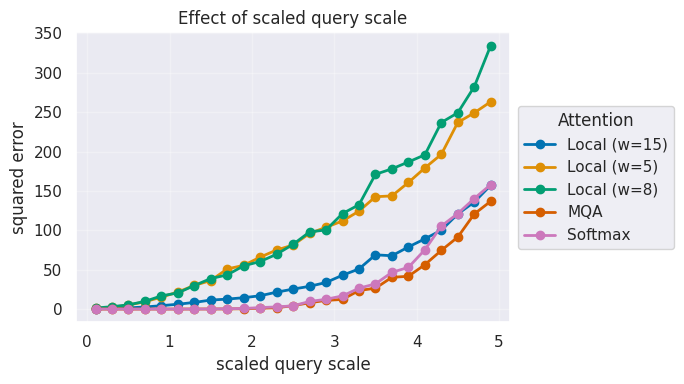

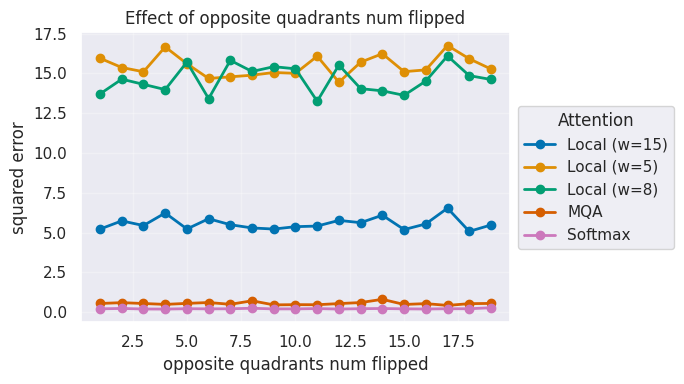

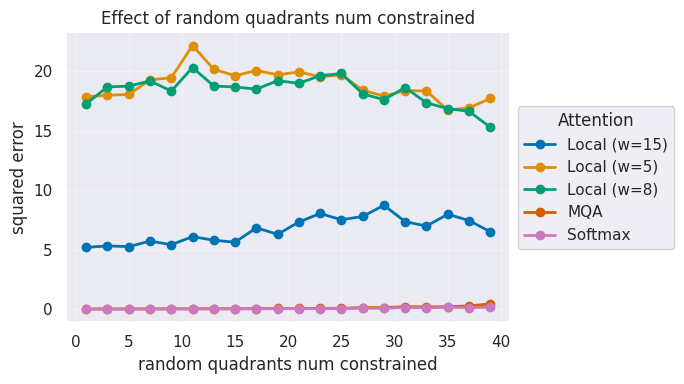

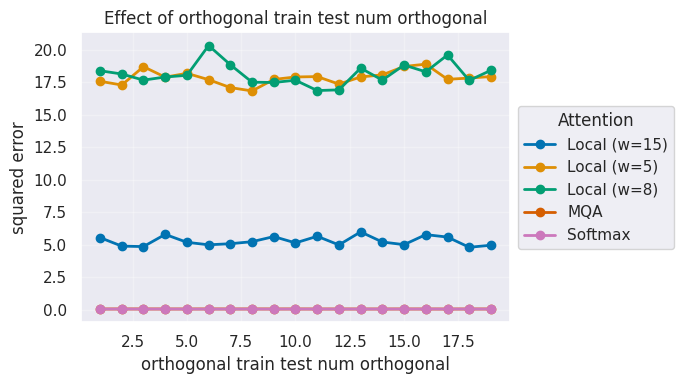

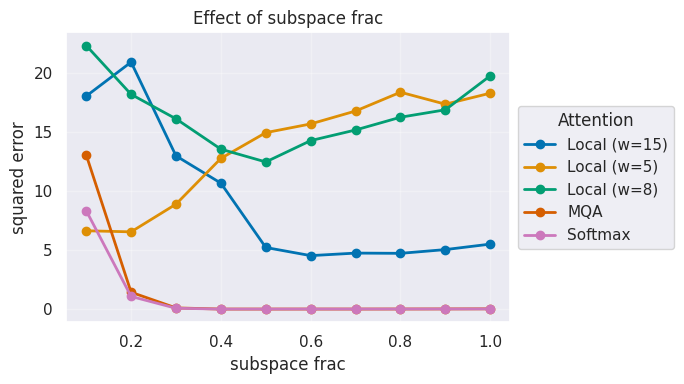

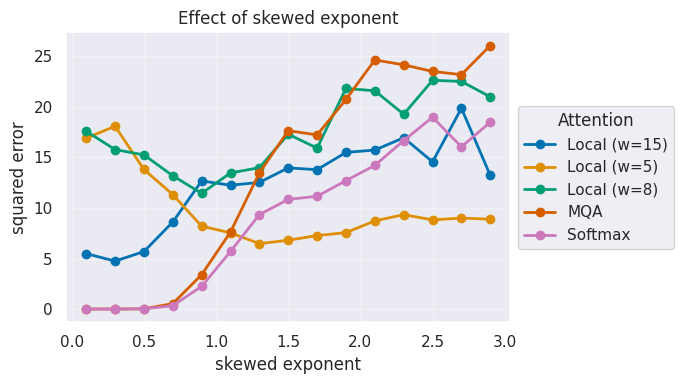

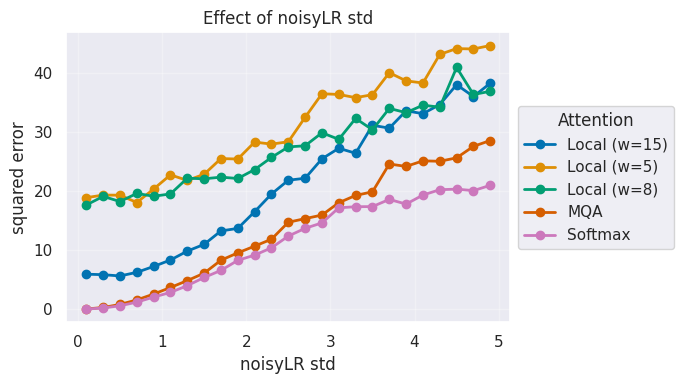

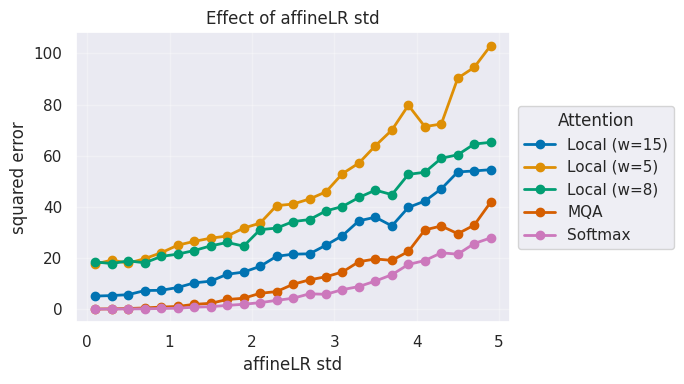

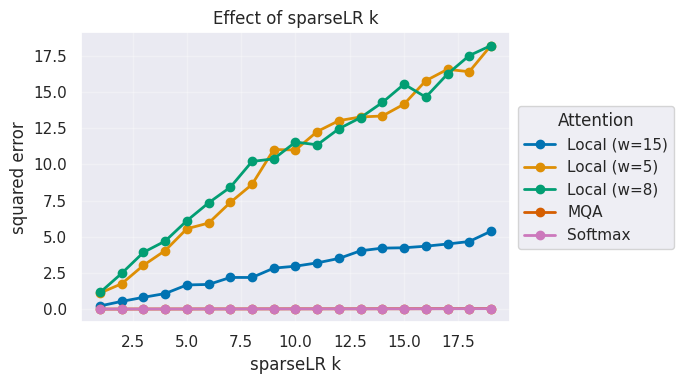

In [6]:
# Plot all parameter sweep experiments (comparing all models)
figs = plot_param_sweep(results)

for fig in figs:
    plt.show()

# Plotting Multiple Models

The code above loads metrics from all models specified in `run_ids` and combines them into a single `results` dictionary. Each graph will show one line per model for comparison.

You can:
1. **Add more models**: Just add their run_ids to the `run_ids` list in the cell above
2. **Plot parameter sweeps**: The cell below plots all parameter sweep experiments
3. **Plot specific experiments**: Use `plot_experiment()` to plot a single experiment type

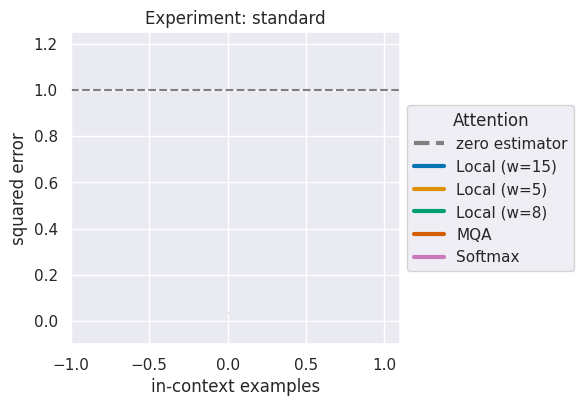

In [7]:
# Example: Plot a specific experiment comparing all models

# Plot the "standard" experiment
fig, ax = plot_experiment(results, "standard")
if fig:
    plt.show()

# You can also plot other experiments like:
# fig, ax = plot_experiment(results, "noisyLR_std=1.0")
# fig, ax = plot_experiment(results, "scaled_query_scale=2.0")
# etc.